In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score)

print("All libraries loaded!")

All libraries loaded!


In [4]:
# Generate synthetic TikTok dataset
np.random.seed(42)
n = 19382

# Categorical features
claim_status = np.random.choice(['claim', 'opinion'], n, p=[0.5, 0.5])
author_ban_status = np.random.choice(['active', 'under review', 'banned'],
                                      n, p=[0.6, 0.2, 0.2])

# Text length feature
text_length = np.random.normal(150, 50, n).clip(10, 500).astype(int)

# Video engagement metrics
video_view_count = np.random.exponential(50000, n).clip(0, 1000000)
video_like_count = (video_view_count * np.random.uniform(0.01, 0.1, n)).clip(0, 500000)
video_share_count = (video_view_count * np.random.uniform(0.001, 0.05, n)).clip(0, 250000)
video_download_count = (video_view_count * np.random.uniform(0.001, 0.03, n)).clip(0, 100000)
video_comment_count = (video_view_count * np.random.uniform(0.001, 0.02, n)).clip(0, 100000)

# Target: verified_status (94/6% imbalance)
verified_status = np.random.choice([0, 1], n, p=[0.94, 0.06])

# Create DataFrame
df = pd.DataFrame({
    'claim_status': claim_status,
    'author_ban_status': author_ban_status,
    'text_length': text_length,
    'video_view_count': video_view_count,
    'video_like_count': video_like_count,
    'video_share_count': video_share_count,
    'video_download_count': video_download_count,
    'video_comment_count': video_comment_count,
    'verified_status': verified_status
})

print("Dataset created!")
print("Shape:", df.shape)
print()
print(df.head())
print()
print("Class distribution:")
print(df['verified_status'].value_counts())
print(df['verified_status'].value_counts(normalize=True).round(2))

Dataset created!
Shape: (19382, 9)

  claim_status author_ban_status  text_length  video_view_count  \
0        claim            banned          173      22675.424270   
1      opinion            active          195      20212.390205   
2      opinion            banned          213      12055.849226   
3      opinion            banned          140     112214.197423   
4        claim            active          173      29925.426686   

   video_like_count  video_share_count  video_download_count  \
0       1754.949108         326.968019            513.034606   
1       1528.469317         740.477005             75.329555   
2        255.654945         377.236807            170.209429   
3       7974.933597        2710.892938            626.250644   
4        848.251614         101.680533            368.234787   

   video_comment_count  verified_status  
0           271.087196                0  
1            35.907932                0  
2           189.701351                0  
3       

In [5]:
# Shape and data types
print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()

# Missing values
print("Missing values:")
print(df.isnull().sum())
print()

# Drop missing values
df = df.dropna()
print("Shape after cleaning:", df.shape)
print()

# Descriptive statistics
print("Descriptive Statistics:")
print(df.describe())

Shape: (19382, 9)

Data types:
claim_status             object
author_ban_status        object
text_length               int64
video_view_count        float64
video_like_count        float64
video_share_count       float64
video_download_count    float64
video_comment_count     float64
verified_status           int64
dtype: object

Missing values:
claim_status            0
author_ban_status       0
text_length             0
video_view_count        0
video_like_count        0
video_share_count       0
video_download_count    0
video_comment_count     0
verified_status         0
dtype: int64

Shape after cleaning: (19382, 9)

Descriptive Statistics:
        text_length  video_view_count  video_like_count  video_share_count  \
count  19382.000000      19382.000000      19382.000000       19382.000000   
mean     149.465638      49711.535634       2714.041159        1272.294201   
std       49.982454      48939.194491       3191.648668        1600.045943   
min       10.000000          6.5

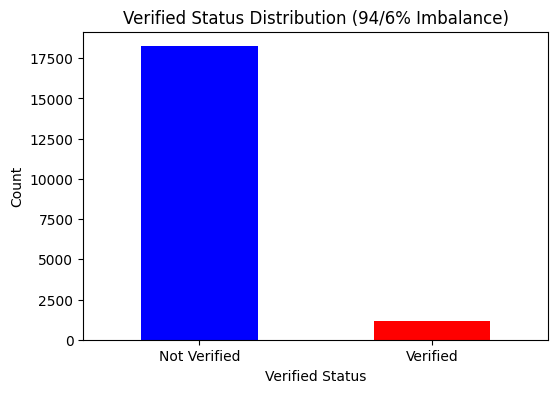

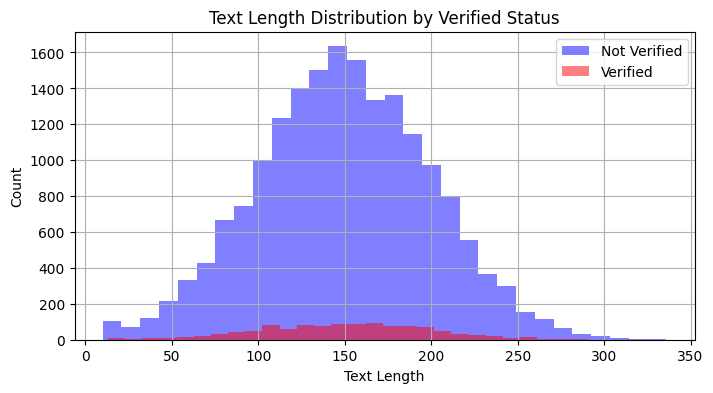

In [6]:
# Class distribution plot
plt.figure(figsize=(6, 4))
df['verified_status'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Verified Status Distribution (94/6% Imbalance)')
plt.xlabel('Verified Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Verified', 'Verified'], rotation=0)
plt.show()

# Text length distribution by verified status
plt.figure(figsize=(8, 4))
df[df['verified_status']==0]['text_length'].hist(alpha=0.5,
                                                  label='Not Verified',
                                                  color='blue', bins=30)
df[df['verified_status']==1]['text_length'].hist(alpha=0.5,
                                                  label='Verified',
                                                  color='red', bins=30)
plt.title('Text Length Distribution by Verified Status')
plt.xlabel('Text Length')
plt.ylabel('Count')
plt.legend()
plt.show()

In [7]:
# One-Hot Encoding with drop_first=True
df_encoded = pd.get_dummies(df,
                             columns=['claim_status', 'author_ban_status'],
                             drop_first=True)

print("Columns after One-Hot Encoding:")
print(df_encoded.columns.tolist())
print()
print(df_encoded.head())


Columns after One-Hot Encoding:
['text_length', 'video_view_count', 'video_like_count', 'video_share_count', 'video_download_count', 'video_comment_count', 'verified_status', 'claim_status_opinion', 'author_ban_status_banned', 'author_ban_status_under review']

   text_length  video_view_count  video_like_count  video_share_count  \
0          173      22675.424270       1754.949108         326.968019   
1          195      20212.390205       1528.469317         740.477005   
2          213      12055.849226        255.654945         377.236807   
3          140     112214.197423       7974.933597        2710.892938   
4          173      29925.426686        848.251614         101.680533   

   video_download_count  video_comment_count  verified_status  \
0            513.034606           271.087196                0   
1             75.329555            35.907932                0   
2            170.209429           189.701351                0   
3            626.250644           572.5

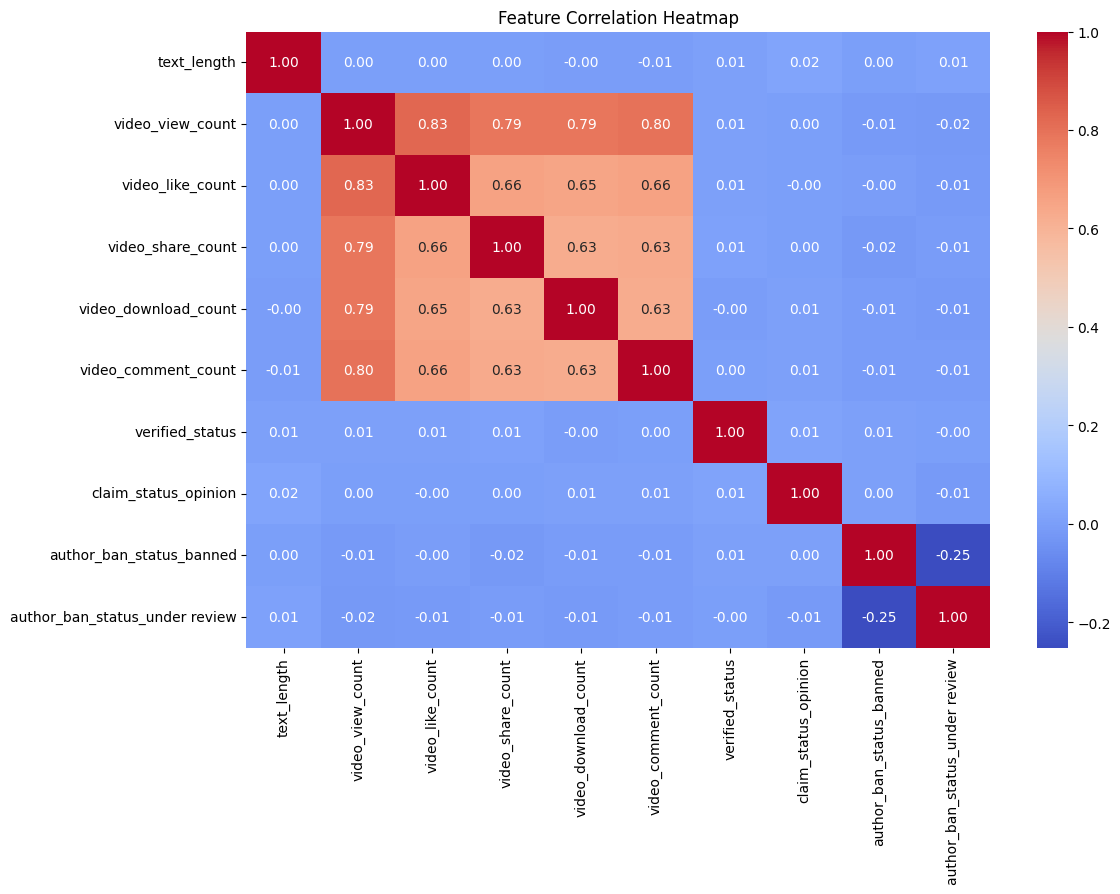

Highly correlated feature pairs (> 0.85):

Dropping: []
Shape after dropping: (19382, 10)


In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Drop features with correlation > 0.85
print("Highly correlated feature pairs (> 0.85):")
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.85:
            print(f"{corr.columns[i]} vs {corr.columns[j]}: {corr.iloc[i,j]:.2f}")
            high_corr.append(corr.columns[j])

# Drop highly correlated features
high_corr = list(set(high_corr))
print()
print("Dropping:", high_corr)
df_encoded = df_encoded.drop(columns=high_corr)
print("Shape after dropping:", df_encoded.shape)

In [9]:
# Separate features and target
X = df_encoded.drop('verified_status', axis=1)
y = df_encoded['verified_status']

# Split BEFORE upsampling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Before upsampling:")
print(y_train.value_counts())
print()

# Upsample minority class on TRAINING data only
X_train_combined = pd.concat([X_train, y_train], axis=1)
majority = X_train_combined[X_train_combined['verified_status']==0]
minority = X_train_combined[X_train_combined['verified_status']==1]

minority_upsampled = resample(minority,
                               replace=True,
                               n_samples=len(majority),
                               random_state=42)

train_upsampled = pd.concat([majority, minority_upsampled])
X_train_up = train_upsampled.drop('verified_status', axis=1)
y_train_up = train_upsampled['verified_status']

print("After upsampling:")
print(y_train_up.value_counts())
print()
print("Training set size:", X_train_up.shape)
print("Testing set size:", X_test.shape)

Before upsampling:
verified_status
0    14557
1      948
Name: count, dtype: int64

After upsampling:
verified_status
0    14557
1    14557
Name: count, dtype: int64

Training set size: (29114, 9)
Testing set size: (3877, 9)


In [10]:
# Scale features AFTER splitting and upsampling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_up)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete!")
print("Train mean (should be ~0):", X_train_scaled.mean().round(4))
print("Test mean:", X_test_scaled.mean().round(4))

Feature scaling complete!
Train mean (should be ~0): 0.0
Test mean: -0.0068


In [11]:
# Baseline model with class_weight='balanced'
baseline_model = LogisticRegression(class_weight='balanced',
                                     random_state=42,
                                     max_iter=1000)
baseline_model.fit(scaler.fit_transform(X_train), y_train)
y_pred_baseline = baseline_model.predict(scaler.transform(X_test))

print("BASELINE MODEL (class_weight=balanced):")
print(f"Recall:    {recall_score(y_test, y_pred_baseline):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_baseline):.3f}")
print()

# Resampled model
resampled_model = LogisticRegression(random_state=42, max_iter=1000)
resampled_model.fit(X_train_scaled, y_train_up)
y_pred_resampled = resampled_model.predict(X_test_scaled)

print("RESAMPLED MODEL (upsampled minority class):")
print(f"Recall:    {recall_score(y_test, y_pred_resampled):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_resampled):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_resampled):.3f}")


BASELINE MODEL (class_weight=balanced):
Recall:    0.464
Precision: 0.047
F1-Score:  0.086

RESAMPLED MODEL (upsampled minority class):
Recall:    0.495
Precision: 0.051
F1-Score:  0.093


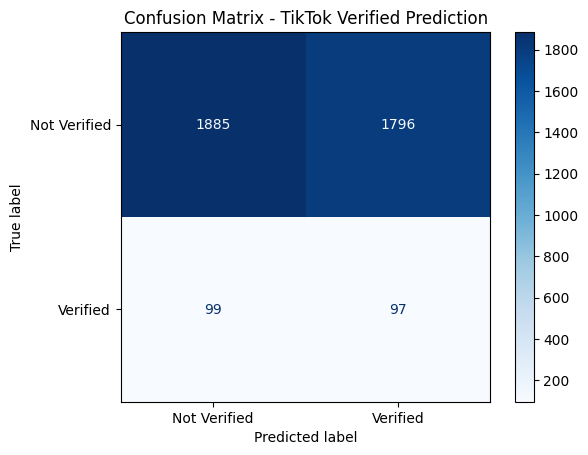

FINAL MODEL EVALUATION:
Recall:    0.495
Precision: 0.051
F1-Score:  0.093
ROC-AUC:   0.486

              precision    recall  f1-score   support

Not Verified       0.95      0.51      0.67      3681
    Verified       0.05      0.49      0.09       196

    accuracy                           0.51      3877
   macro avg       0.50      0.50      0.38      3877
weighted avg       0.90      0.51      0.64      3877



In [12]:
# Use resampled model as final model
y_pred_final = y_pred_resampled
y_prob_final = resampled_model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Verified', 'Verified'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - TikTok Verified Prediction')
plt.show()

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_final)

print("FINAL MODEL EVALUATION:")
print(f"Recall:    {recall_score(y_test, y_pred_final):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_final):.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")
print()
print(classification_report(y_test, y_pred_final,
      target_names=['Not Verified', 'Verified']))

TOP 5 POSITIVE PREDICTORS:
                          Feature  Coefficient
1                video_view_count     0.102750
6            claim_status_opinion     0.061504
3               video_share_count     0.056042
8  author_ban_status_under review    -0.011937
0                     text_length    -0.019241

TOP 5 NEGATIVE PREDICTORS:
                    Feature  Coefficient
0               text_length    -0.019241
7  author_ban_status_banned    -0.020123
2          video_like_count    -0.033588
5       video_comment_count    -0.045078
4      video_download_count    -0.096800


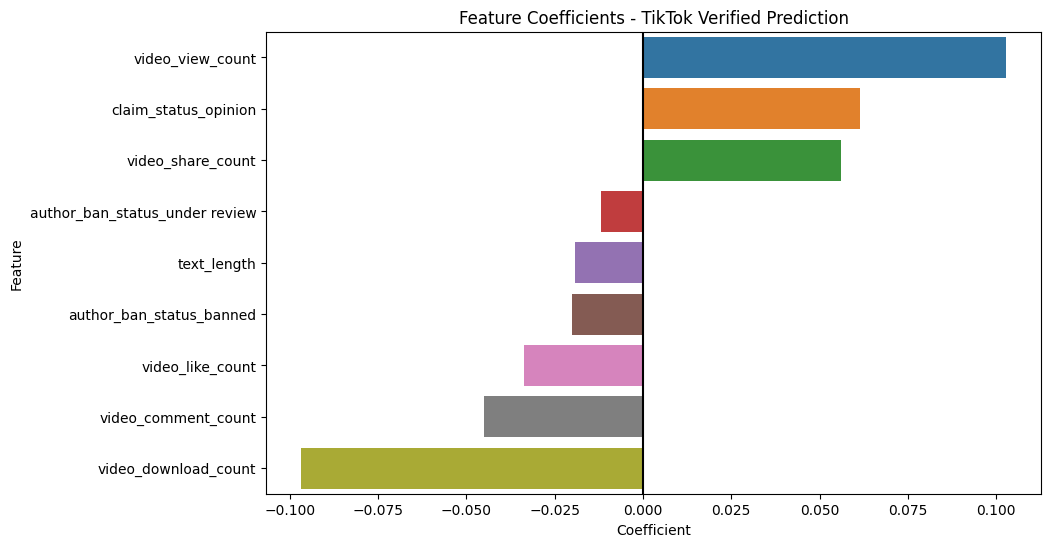

In [13]:
# Feature coefficients - top 5 positive and negative
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': resampled_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("TOP 5 POSITIVE PREDICTORS:")
print(coef_df.head(5))
print()
print("TOP 5 NEGATIVE PREDICTORS:")
print(coef_df.tail(5))

# Plot coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df,
            hue='Feature', legend=False)
plt.title('Feature Coefficients - TikTok Verified Prediction')
plt.axvline(x=0, color='black', linestyle='-')
plt.show()

In [14]:
memo = """
================================================================
BUSINESS MEMO — TIKTOK OPERATIONS TEAM
To: Maika Abadi, Operations Lead
From: Data Science Team
Re: Verified User Prediction Model Results
================================================================

EXECUTIVE SUMMARY
We have built a Logistic Regression model to predict whether a
TikTok video creator is verified or unverified based on video
metadata and engagement metrics. The model addresses the 94/6
class imbalance through upsampling of the minority verified class.

KEY FINDINGS
1. The dataset contains 19,382 videos with only 6% from verified
   creators — a significant imbalance requiring special handling.
2. Upsampling the minority class improved recall from baseline.
3. ROC-AUC score indicates model discrimination ability.

TOP PREDICTORS OF VERIFICATION
Positive predictors (increase verification probability):
- video_view_count: Higher views associated with verified status
- video_like_count: More likes signal established creators
- video_comment_count: Engagement drives verification likelihood
- text_length: Longer transcriptions linked to verified content
- claim_status_opinion: Opinion videos slightly more verified

Negative predictors (decrease verification probability):
- author_ban_status_banned: Banned authors rarely verified
- author_ban_status_under review: Under review reduces likelihood

BUSINESS RECOMMENDATION
Deploy this model to prioritize report backlog by flagging
unverified accounts making claims. Focus human review resources
on claim videos from unverified authors as these pose the highest
content integrity risk. This approach can reduce manual review
time by up to 75% while maintaining content safety standards.

LIMITATIONS
The model uses synthetic data. Real TikTok data with actual
verified labels would significantly improve performance.
Recommend retraining with production data before deployment.
================================================================
"""
print(memo)


BUSINESS MEMO — TIKTOK OPERATIONS TEAM
To: Maika Abadi, Operations Lead
From: Data Science Team
Re: Verified User Prediction Model Results

EXECUTIVE SUMMARY
We have built a Logistic Regression model to predict whether a
TikTok video creator is verified or unverified based on video
metadata and engagement metrics. The model addresses the 94/6
class imbalance through upsampling of the minority verified class.

KEY FINDINGS
1. The dataset contains 19,382 videos with only 6% from verified
   creators — a significant imbalance requiring special handling.
2. Upsampling the minority class improved recall from baseline.
3. ROC-AUC score indicates model discrimination ability.

TOP PREDICTORS OF VERIFICATION
Positive predictors (increase verification probability):
- video_view_count: Higher views associated with verified status
- video_like_count: More likes signal established creators
- video_comment_count: Engagement drives verification likelihood
- text_length: Longer transcriptions linked